#   How does population vary across the districts and divisions of Bangladesh?

## 1. Setup & Data Loading

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("housing_census_cleaned.csv")

In [3]:
df.head(5)

,division,district,division_geocode,district_geocode,household_total,population_total,household_excluding_slum_floating,population_excluding_slum_floating,household_slum,population_slum,...,number_of_person_avg_hh_size__of_hh_with_3person,number_of_person_avg_hh_size__of_hh_with_4person,number_of_person_avg_hh_size__of_hh_with_5person,number_of_person_avg_hh_size__of_hh_with_6person,number_of_person_avg_hh_size__of_hh_with_7person,number_of_person_avg_hh_size__of_hh_with_8person,number_of_person_avg_hh_size__of_hh_with_9person,number_of_person_avg_hh_size__of_hh_with_10person,number_of_person_avg_hh_size__of_hh_with_10person_,number_of_person_avg_hh_size_average_household_size
0,Barishal,Barguna,10,4,255390,1010531,254895,1008695,451,1789,...,57097,68828,43330,20901,8395,3499,1583,772,767,3.92
1,Khulna,Bagerhat,40,1,408840,1613076,406058,1603126,2605,9763,...,96057,109638,68442,32081,12933,5722,2560,1324,1236,3.89
2,Barishal,Barishal,10,6,629626,2570446,620735,2537292,8160,31338,...,135271,165285,110132,54039,23613,10535,5289,2819,2981,4.02
3,Barishal,Bhola,10,9,449057,1932518,448944,1932138,74,339,...,89014,118802,92260,46329,20396,9347,4588,2375,2574,4.27
4,Barishal,Jhalokati,10,42,162401,661160,162212,660520,143,588,...,34540,41357,27852,14052,6339,3084,1529,815,904,4.02


In [4]:
df.tail(5)

,division,district,division_geocode,district_geocode,household_total,population_total,household_excluding_slum_floating,population_excluding_slum_floating,household_slum,population_slum,...,number_of_person_avg_hh_size__of_hh_with_3person,number_of_person_avg_hh_size__of_hh_with_4person,number_of_person_avg_hh_size__of_hh_with_5person,number_of_person_avg_hh_size__of_hh_with_6person,number_of_person_avg_hh_size__of_hh_with_7person,number_of_person_avg_hh_size__of_hh_with_8person,number_of_person_avg_hh_size__of_hh_with_9person,number_of_person_avg_hh_size__of_hh_with_10person,number_of_person_avg_hh_size__of_hh_with_10person_,number_of_person_avg_hh_size_average_household_size
59,Rangpur,Panchagarh,55,77,281627,1179843,280851,1176974,735,2827,...,56319,81106,53595,26636,11085,4651,2404,1281,1416,4.14
60,Rangpur,Rangpur,55,85,834307,3169614,826692,3141432,7447,28003,...,203689,231968,124275,52856,20364,8494,4142,2101,2248,3.72
61,Rangpur,Thakurgaon,55,94,382400,1533895,381262,1529809,1021,3930,...,82779,112589,66032,30798,11940,4898,2590,1297,1416,3.96
62,Sylhet,Sunamganj,60,90,528550,2695496,527545,2691484,865,3868,...,70460,104937,105541,78260,48226,27163,14596,8854,13911,5.09
63,Sylhet,Sylhet,60,91,746854,3857123,722553,3753617,23853,103032,...,102825,152780,143801,101254,62353,36293,21359,13723,24742,5.13


## Names of all divisions and districts.

In [5]:

for division, grp in df.groupby('division'):
    districts = sorted(grp['district'].unique())
    print(f"{division}: {', '.join(districts)}")

Barishal: Barguna, Barishal, Bhola, Jhalokati, Patuakhali, Pirojpur
Chattogram: Bandarban, Brahmanbaria, Chandpur, Chattogram, Cox's Bazar, Cumilla, Feni, Khagrachhari, Lakshmipur, Noakhali, Rangamati
Dhaka: Dhaka, Faridpur, Gazipur, Gopalganj, Kishoreganj, Madaripur, Manikganj, Munshiganj, Narayanganj, Narsingdi, Rajbari, Shariatpur, Tangail
Khulna: Bagerhat, Chuadanga, Jashore, Jhenaidah, Khulna, Kushtia, Magura, Meherpur, Narail, Satkhira
Mymensingh: Jamalpur, Mymensingh, Netrakona, Sherpur
Rajshahi: Bogura, Chapainababganj, Joypurhat, Naogaon, Natore, Pabna, Rajshahi, Sirajganj
Rangpur: Dinajpur, Gaibandha, Kurigram, Lalmonirhat, Nilphamari, Panchagarh, Rangpur, Thakurgaon
Sylhet: Habiganj, Moulvibazar, Sunamganj, Sylhet


In [6]:

df_sorted = df.sort_values( by=["division", "district", "population_total"], ascending=[True, True, False])

print(df_sorted[["division", "district", "population_total"]].to_string())

      division         district  population_total
0     Barishal          Barguna           1010531
2     Barishal         Barishal           2570446
3     Barishal            Bhola           1932518
4     Barishal        Jhalokati            661160
6     Barishal       Patuakhali           1727254
7     Barishal         Pirojpur           1198195
5   Chattogram        Bandarban            481106
8   Chattogram     Brahmanbaria           3306563
9   Chattogram         Chandpur           2635748
11  Chattogram       Chattogram           9169465
13  Chattogram      Cox's Bazar           6212216
12  Chattogram          Cumilla           2823268
14  Chattogram             Feni           1648896
15  Chattogram     Khagrachhari            714119
16  Chattogram       Lakshmipur           1937948
18  Chattogram         Noakhali           3625442
19  Chattogram        Rangamati            647586
20       Dhaka            Dhaka          14734701
21       Dhaka         Faridpur           2162879


### Horizontal bar charts were used for the division with the highest number of districts, while vertical bar charts were used for the one with the lowest.

## Population Distribution of Barishal Division

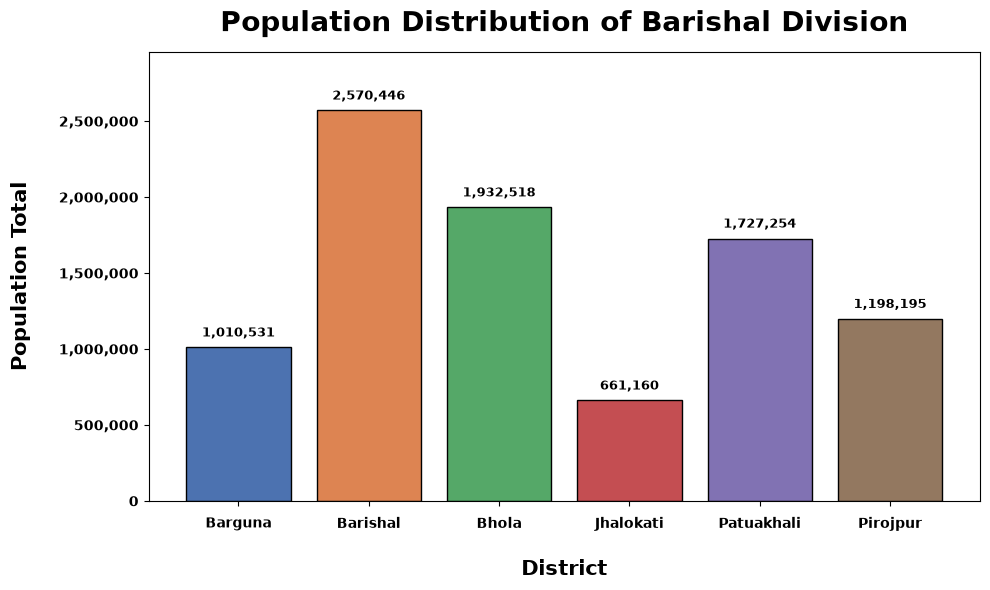

In [7]:

barishal = df[df["division"] == "Barishal"].sort_values("district")

plt.figure(figsize=(10, 6),dpi=100)

colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860"]

bars = plt.bar( barishal["district"], barishal["population_total"], color=colors, edgecolor="black")

plt.xlabel("District", fontsize=15, fontweight="bold", labelpad=20)
plt.ylabel("Population Total", fontsize=15, fontweight="bold", labelpad=20)
plt.title( "Population Distribution of Barishal Division", fontsize=20, fontweight="bold", pad=15)

plt.xticks(rotation=0, ha="center", fontsize=10, fontweight="bold")
plt.yticks(fontsize=10, fontweight="bold")
plt.tick_params(axis="x", pad=8) 
plt.ticklabel_format(style="plain", axis="y")

plt.gca().get_yaxis().set_major_formatter( plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

max_val = barishal["population_total"].max()

for bar in bars:
  height = bar.get_height()
  plt.text( bar.get_x() + bar.get_width() / 2, height + (max_val * 0.02), f"{int(height):,}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

plt.ylim(0, max_val * 1.15)

plt.tight_layout()

plt.savefig("Population Distribution of Barishal Division.png", dpi=300)
plt.show()

## Population Distribution of Chattogram Division

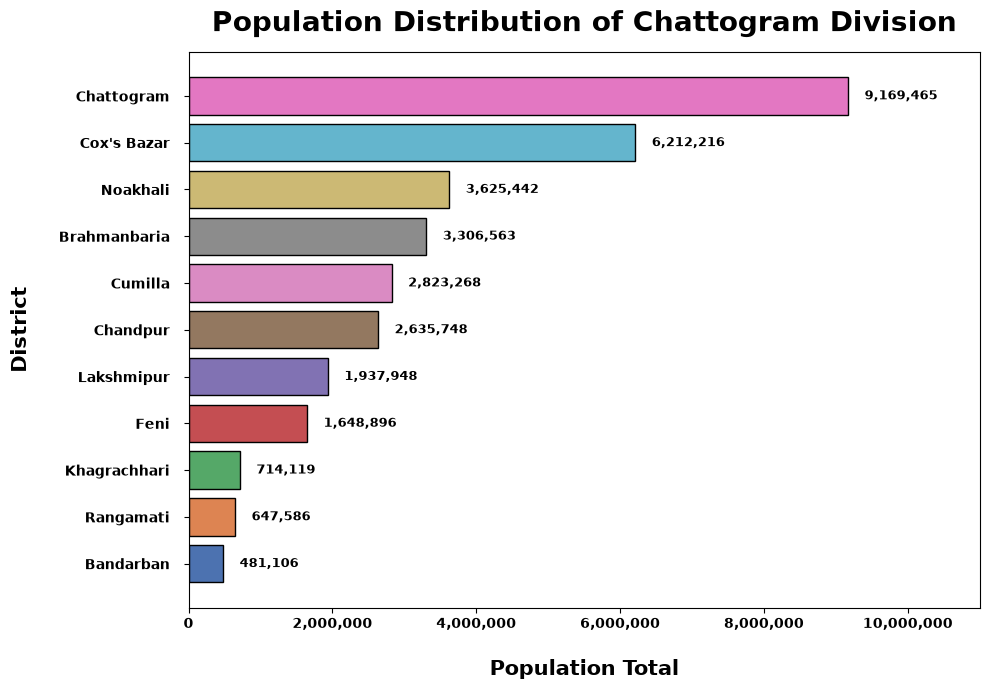

In [8]:

chattogram = df[df["division"] == "Chattogram"].sort_values( "population_total", ascending=True)

plt.figure(figsize=(10, 7),dpi=100)

colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860", "#da8bc3",
    "#8c8c8c","#ccb974","#64b5cd","#e377c2"]

bars = plt.barh( chattogram["district"], chattogram["population_total"], color=colors, edgecolor="black")

plt.xlabel("Population Total", fontsize=15, fontweight="bold", labelpad=20)
plt.ylabel("District", fontsize=15, fontweight="bold", labelpad=20)

plt.title( "Population Distribution of Chattogram Division", fontsize=20, fontweight="bold", pad=15)
plt.ticklabel_format(style="plain", axis="x")

plt.gca().get_xaxis().set_major_formatter( plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))


plt.yticks(fontsize=10, fontweight="bold")
plt.xticks(fontsize=10, fontweight="bold")
plt.tick_params(axis="y", pad=10)  


max_val = chattogram["population_total"].max()

for bar in bars:
  width = bar.get_width()
  plt.text( width + (max_val * 0.025), bar.get_y() + bar.get_height() / 2, f"{int(width):,}", ha="left", va="center", fontsize=9.5, fontweight="bold")

plt.xlim(0, max_val * 1.20)

plt.tight_layout()

plt.savefig("Population Distribution of Chattogram Division.png",dpi=300)
plt.show()

## Population Distribution of Dhaka Division

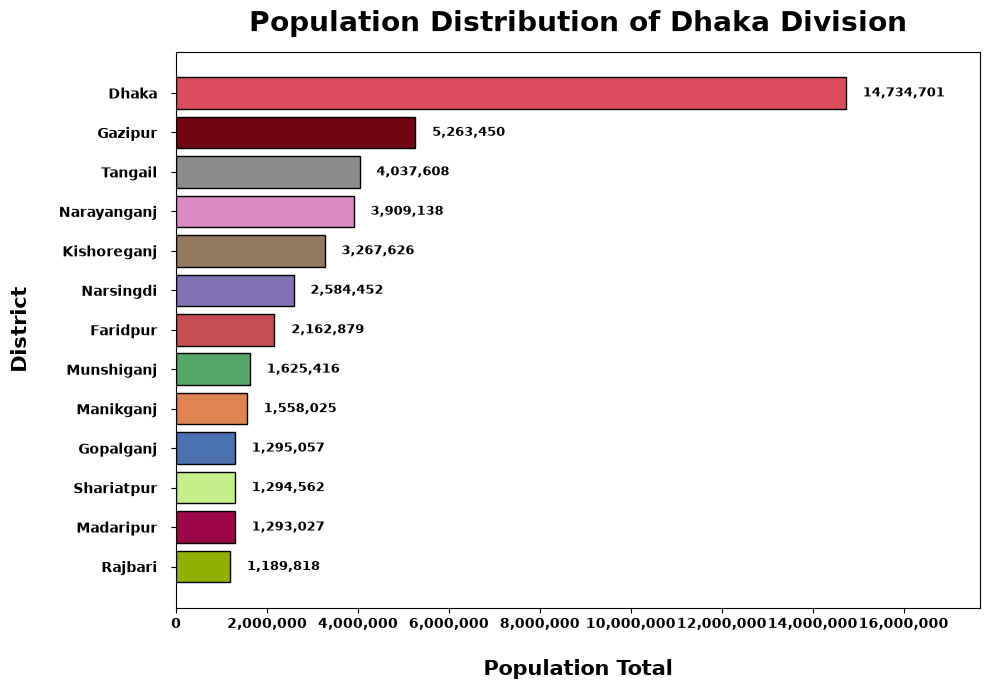

In [9]:
dhaka=df[df["division"]=="Dhaka"].sort_values("population_total",ascending=True)

plt.figure(figsize=(10,7),dpi=100)

colors=["#92b108","#9c0848","#c5ed8a", "#4c72b0", "#dd8452", "#55a868", "#c44e52","#8172b3", "#937860", "#da8bc3","#8c8c8c",
        "#700612" ,"#d94c5c"]

bars=plt.barh(dhaka["district"],dhaka["population_total"],color=colors,edgecolor="black")


plt.xlabel("Population Total", fontsize=15, fontweight="bold", labelpad=20)
plt.ylabel("District", fontsize=15, fontweight="bold", labelpad=20)
plt.title( "Population Distribution of Dhaka Division" ,fontsize=20, fontweight="bold", pad=15)


plt.ticklabel_format(style="plain", axis="x")
plt.gca().get_xaxis().set_major_formatter( plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.yticks(fontsize=10, fontweight="bold")
plt.xticks(fontsize=10, fontweight="bold")
plt.tick_params(axis="y", pad=10)  


max_val = dhaka["population_total"].max()
for bar in bars:
  width = bar.get_width()
  plt.text( width + (max_val * 0.025),  bar.get_y() + bar.get_height() / 2,  f"{int(width):,}", ha="left", va="center", fontsize=9.5, fontweight="bold") 

plt.xlim(0, max_val * 1.20)

plt.tight_layout()

plt.savefig("Population Distribution of Dhaka Division.png",dpi=300)
plt.show()


### Population Distribution of Khulna Division

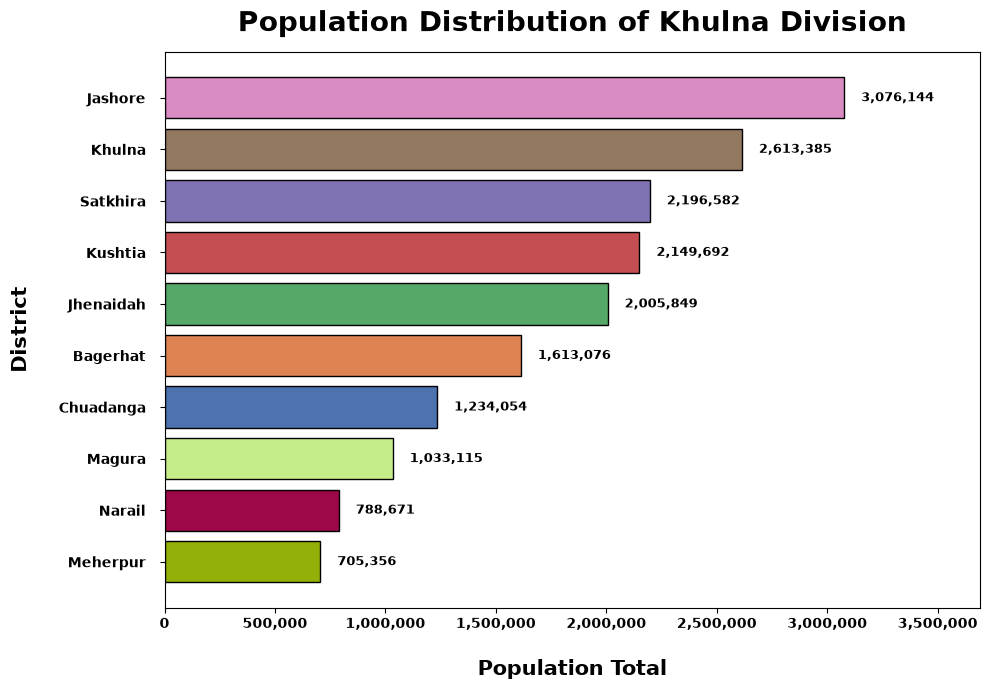

In [10]:
khulna = df[df["division"] == "Khulna"].sort_values( "population_total", ascending=True)

plt.figure(figsize=(10, 7), dpi=100)

colors = ["#92b108", "#9c0848", "#c5ed8a", "#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860",
    "#da8bc3", "#8c8c8c", "#700612", "#d94c5c"]

bars = plt.barh(khulna["district"], khulna["population_total"], color=colors, edgecolor="black")

plt.xlabel("Population Total", fontsize=15, fontweight="bold", labelpad=20)
plt.ylabel("District", fontsize=15, fontweight="bold", labelpad=20)

plt.title( "Population Distribution of Khulna Division", fontsize=20, fontweight="bold", pad=15)

plt.ticklabel_format(style="plain", axis="x")

plt.gca().get_xaxis().set_major_formatter( plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.yticks(fontsize=10, fontweight="bold")
plt.xticks(fontsize=10, fontweight="bold")
plt.tick_params(axis="y", pad=10)

max_val = khulna["population_total"].max()
for bar in bars:
  width = bar.get_width()

  plt.text( width + (max_val * 0.025), bar.get_y() + bar.get_height() / 2, f"{int(width):,}", ha="left", va="center", fontsize=9.5, fontweight="bold")

plt.xlim(0, max_val * 1.20)

plt.tight_layout()

plt.savefig("Population Distribution of Khulna Division.png",dpi=300)
plt.show()

## Population Distribution of Mymensingh Division

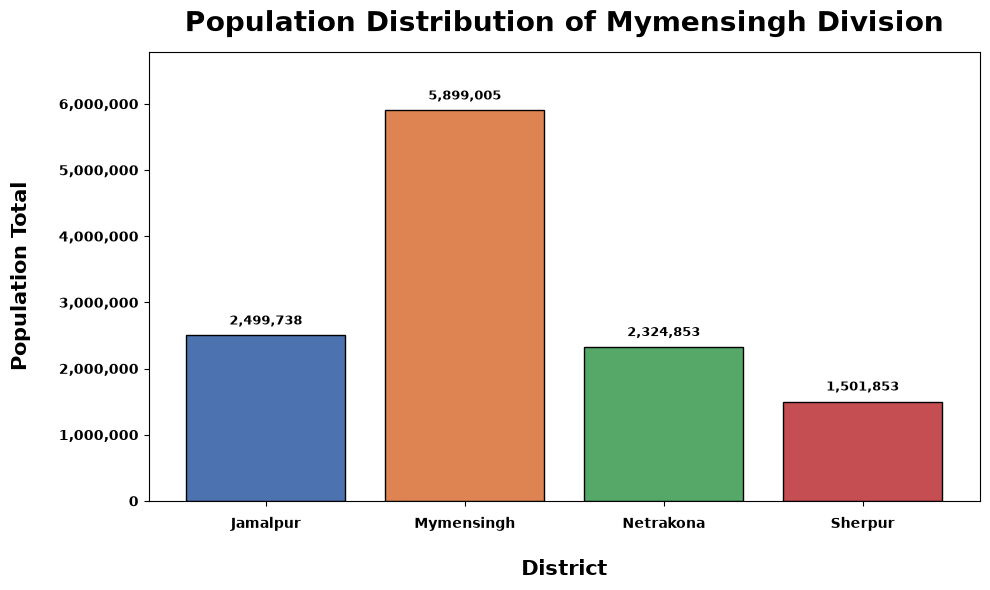

In [11]:


mymensingh = df[df["division"] == "Mymensingh"].sort_values("district")

plt.figure(figsize=(10, 6), dpi=100)

colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]

bars = plt.bar( mymensingh["district"], mymensingh["population_total"], color=colors, edgecolor="black")


plt.xlabel("District", fontsize=15, fontweight="bold", labelpad=20)
plt.ylabel("Population Total", fontsize=15, fontweight="bold", labelpad=20)

plt.title( "Population Distribution of Mymensingh Division", fontsize=20, fontweight="bold",  pad=15 )

plt.xticks(rotation=0, ha="center", fontsize=10, fontweight="bold")
plt.yticks(fontsize=10, fontweight="bold")
plt.tick_params(axis="x", pad=8)

plt.ticklabel_format(style="plain", axis="y")
plt.gca().get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f"{int(x):,}")
)

max_val = mymensingh["population_total"].max()
for bar in bars:
  height = bar.get_height()
  plt.text( bar.get_x() + bar.get_width() / 2, height + (max_val * 0.02), f"{int(height):,}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

plt.ylim(0, max_val * 1.15)
plt.tight_layout()

plt.savefig("Population Distribution of Mymensingh Division.png",dpi=300)
plt.show()

### Population Distribution of Rajshahi Division

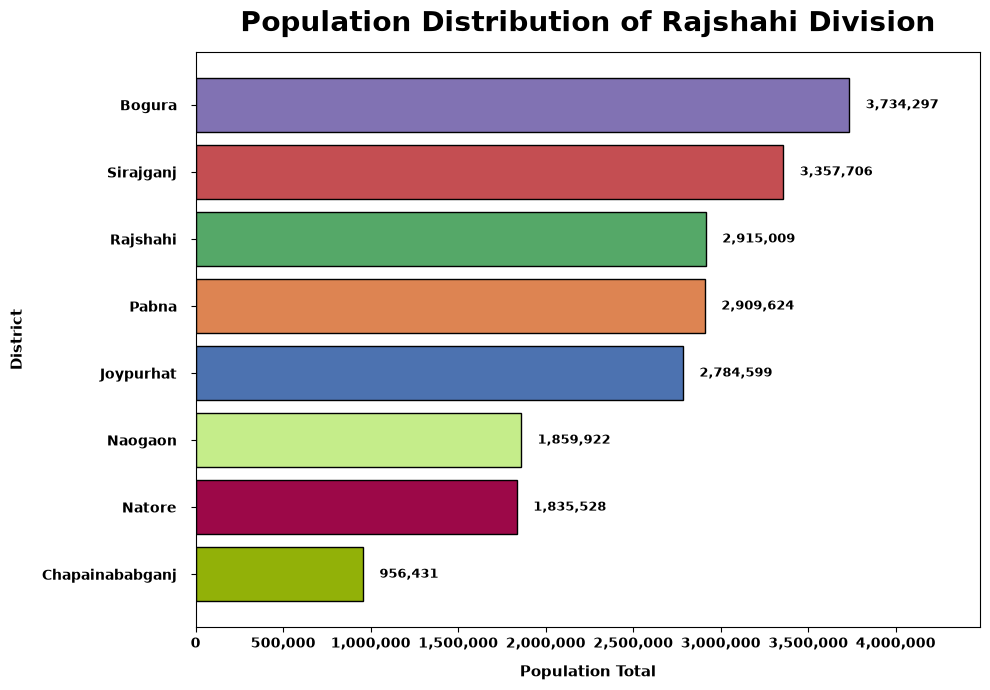

In [12]:
rajshahi = df[df["division"] == "Rajshahi"].sort_values( "population_total", ascending=True)

plt.figure(figsize=(10, 7), dpi=100)

colors = [ "#92b108", "#9c0848", "#c5ed8a", "#4c72b0", "#dd8452",  "#55a868",  "#c44e52", "#8172b3", "#937860", "#da8bc3",
           "#8c8c8c", "#700612", "#d94c5c"]

bars = plt.barh( rajshahi["district"], rajshahi["population_total"], color=colors, edgecolor="black")

plt.xlabel("Population Total", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("District", fontsize=11, fontweight="bold", labelpad=12)

plt.title( "Population Distribution of Rajshahi Division",  fontsize=20, fontweight="bold", pad=15)

plt.ticklabel_format(style="plain", axis="x")

plt.gca().get_xaxis().set_major_formatter( plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.yticks(fontsize=10, fontweight="bold")
plt.xticks(fontsize=10, fontweight="bold")
plt.tick_params(axis="y", pad=10)

max_val = rajshahi["population_total"].max()
for bar in bars:
  width = bar.get_width()
  plt.text(width + (max_val * 0.025), bar.get_y() + bar.get_height() / 2, f"{int(width):,}",ha="left", va="center", fontsize=9.5, fontweight="bold")

plt.xlim(0, max_val * 1.20)

plt.tight_layout()

plt.savefig("Population Distribution of Rajshahi Division.png",dpi=300)
plt.show()

## Population Distribution of Rangpur Division

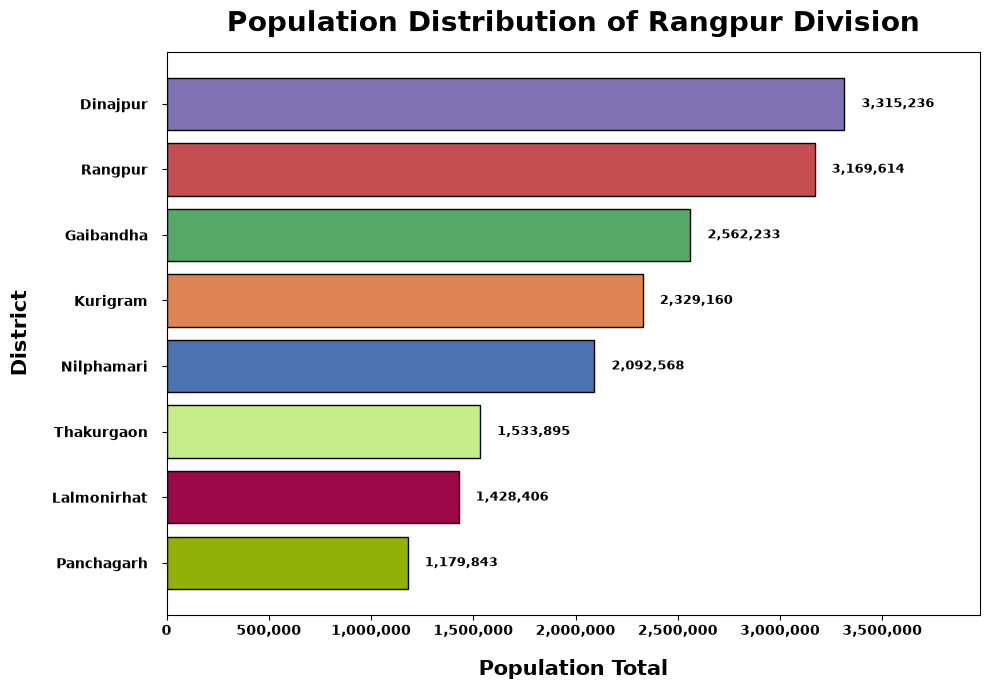

In [13]:
rangpur = df[df["division"] == "Rangpur"].sort_values( "population_total", ascending=True)

plt.figure(figsize=(10, 7), dpi=100)

colors = [ "#92b108", "#9c0848", "#c5ed8a", "#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860", "#da8bc3",
           "#8c8c8c", "#700612", "#d94c5c"]

bars = plt.barh(rangpur["district"], rangpur["population_total"], color=colors, edgecolor="black")

plt.xlabel("Population Total", fontsize=15, fontweight="bold", labelpad=15)
plt.ylabel("District", fontsize=15, fontweight="bold", labelpad=15)
plt.title( "Population Distribution of Rangpur Division", fontsize=20, fontweight="bold", pad=15)

plt.ticklabel_format(style="plain", axis="x")
plt.gca().get_xaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f"{int(x):,}")
)

plt.yticks(fontsize=10, fontweight="bold")
plt.xticks(fontsize=10, fontweight="bold")
plt.tick_params(axis="y", pad=10)

max_val = rangpur["population_total"].max()
for bar in bars:
  width = bar.get_width()

  plt.text( width + (max_val * 0.025), bar.get_y() + bar.get_height() / 2, f"{int(width):,}", ha="left", va="center", fontsize=9.5, fontweight="bold")

plt.xlim(0, max_val * 1.20)

plt.tight_layout()

plt.savefig("Population Distribution of Rangpur Division.png", dpi=300)

plt.show()

## Population Distribution of Sylhet Division

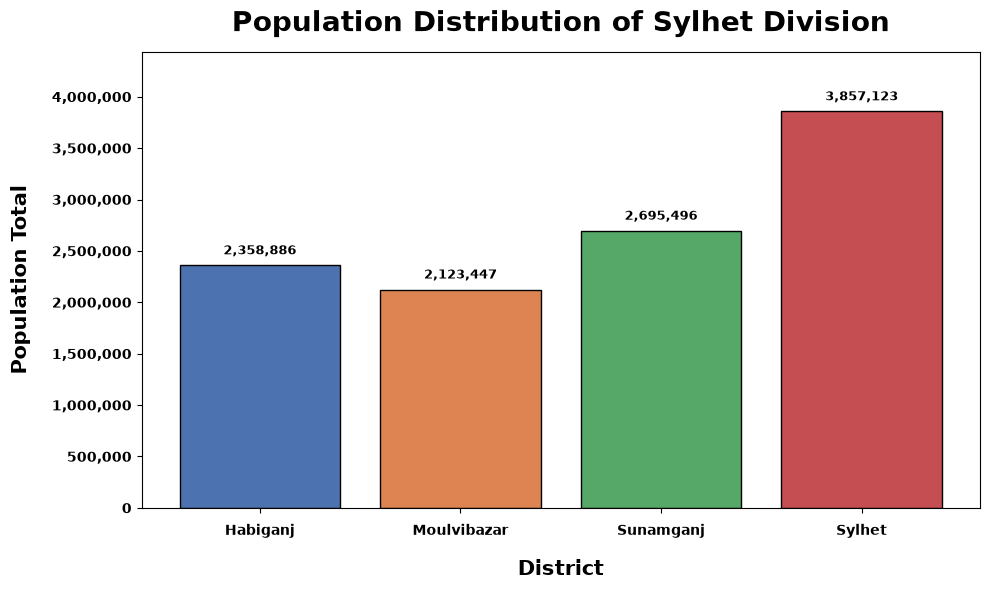

In [14]:

sylhet = df[df["division"] == "Sylhet"].sort_values("district")

plt.figure(figsize=(10, 6), dpi=100)

colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]

bars = plt.bar( sylhet["district"], sylhet["population_total"], color=colors, edgecolor="black")

plt.xlabel("District", fontsize=15, fontweight="bold", labelpad=15)
plt.ylabel("Population Total", fontsize=15, fontweight="bold", labelpad=15)


plt.title( "Population Distribution of Sylhet Division", fontsize=20, fontweight="bold",pad=15)

plt.xticks(rotation=0, ha="center", fontsize=10, fontweight="bold")
plt.yticks(fontsize=10, fontweight="bold")
plt.tick_params(axis="x", pad=8)


plt.ticklabel_format(style="plain", axis="y")

plt.gca().get_yaxis().set_major_formatter( plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

max_val = sylhet["population_total"].max()
for bar in bars:
  height = bar.get_height()

  plt.text(bar.get_x() + bar.get_width() / 2, height + (max_val * 0.02), f"{int(height):,}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

plt.ylim(0, max_val * 1.15)
plt.tight_layout()

plt.savefig("Population Distribution of Sylhet Division.png",dpi=300)
plt.show()

### Dhaka has the largest share, accounting for 26.8% of the total population. Chattogram comes second, with 20.1% of the country's population. Furthermore, Rajshahi, Kulna, and Rangpur make up 12.3%, 10.5%, and 10.7% of the total population, respectively. However, all the other divisions have a share of less than 10% of the country's population. For instance, Mymensingh and Sylhet represent only 7.4% and 6.7% of the country's population, respectively, while Barishal has the smallest share, at 5.5%.

# 5 most and 5 least populated districts. 

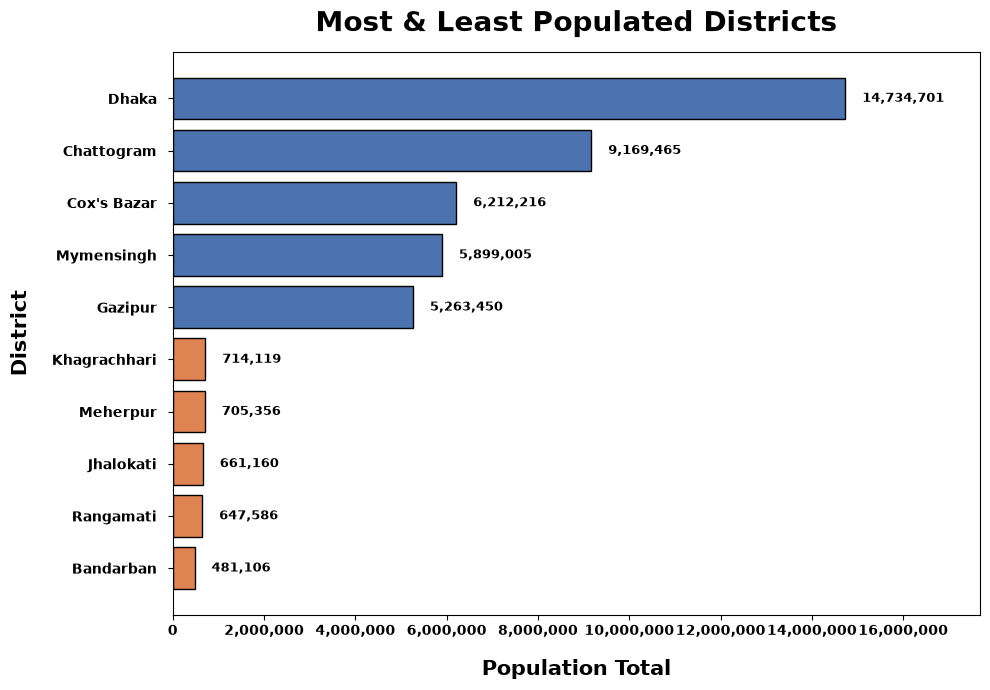

In [15]:

pop_col = "population_total"

df[pop_col] = pd.to_numeric(df[pop_col], errors="coerce")


dist_pop = df.groupby("district")[pop_col].sum()

top5 = dist_pop.nlargest(5)
bottom5 = dist_pop.nsmallest(5)

combined = pd.concat([ bottom5.rename("Population"), top5.rename("Population")]).sort_values()


colors = [ "#dd8452" if district in bottom5.index else "#4c72b0" for district in combined.index ]

plt.figure(figsize=(10, 7), dpi=100)

bars = plt.barh(combined.index, combined.values, color=colors, edgecolor="black")

plt.xlabel("Population Total", fontsize=15, fontweight="bold", labelpad=15)
plt.ylabel("District", fontsize=15, fontweight="bold", labelpad=15)

plt.title( "Most & Least Populated Districts", fontsize=20, fontweight="bold", pad=15)

plt.xticks(fontsize=10, fontweight="bold")
plt.yticks(fontsize=10, fontweight="bold")
plt.tick_params(axis="y", pad=8)

plt.ticklabel_format(style="plain", axis="x")

plt.gca().get_xaxis().set_major_formatter( plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

max_val = combined.max()

for bar in bars:
    width = bar.get_width()

    plt.text( width + (max_val * 0.025), bar.get_y() + bar.get_height() / 2,  f"{int(width):,}", ha="left", va="center", fontsize=9.5, fontweight="bold")

plt.xlim(0, max_val * 1.20)

plt.tight_layout()

plt.savefig("5 most and 5 least populated districts.png",dpi=300)
plt.show()